In [172]:
import numpy as np 
import pandas as pd 
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

/kaggle/input/datasets/adhurimquku/ford-car-price-prediction/ford.csv


In [173]:
df=pd.read_csv("/kaggle/input/datasets/adhurimquku/ford-car-price-prediction/ford.csv")

In [174]:
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0
...,...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,8999,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,7499,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,9999,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,8299,Manual,5007,Petrol,145,57.7,1.2


In [175]:
df.shape

(17966, 9)

In [176]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [177]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [178]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [179]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [180]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

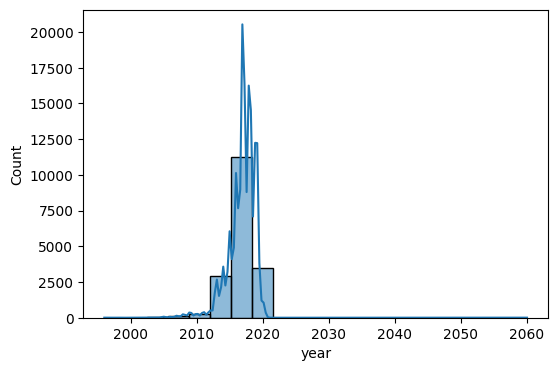

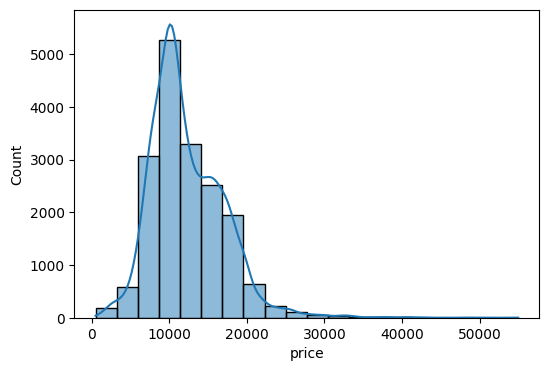

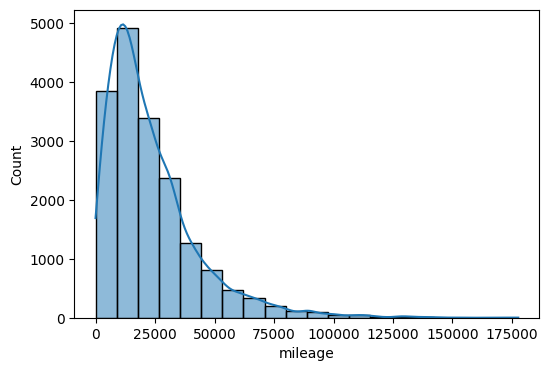

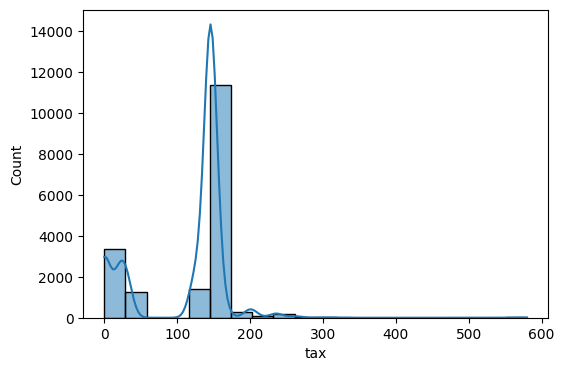

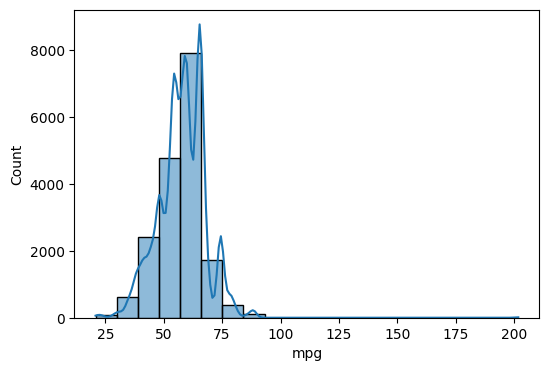

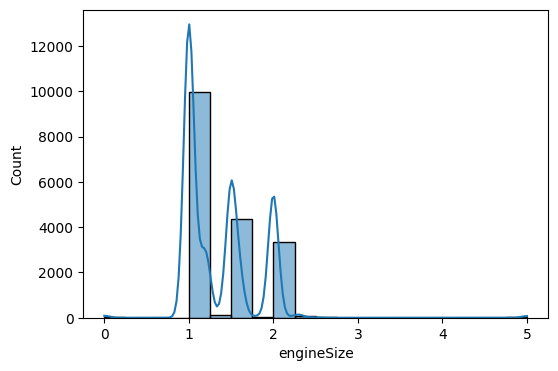

In [181]:
numeric_columns=['year', 'price','mileage','tax',
       'mpg', 'engineSize']
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=20)

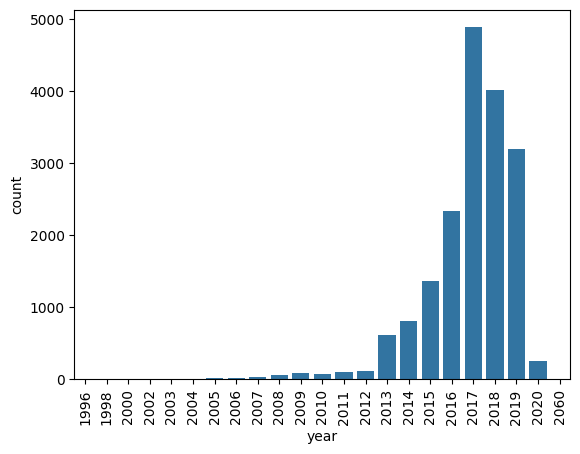

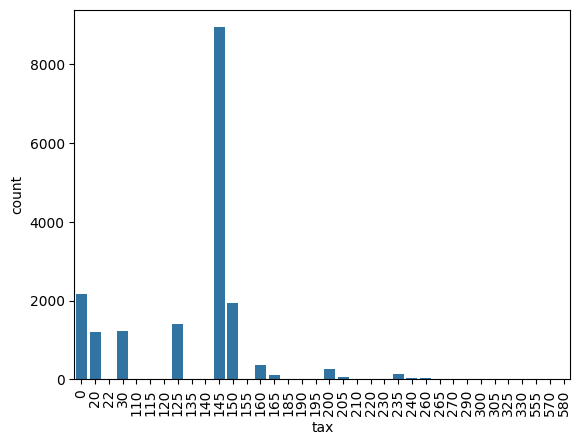

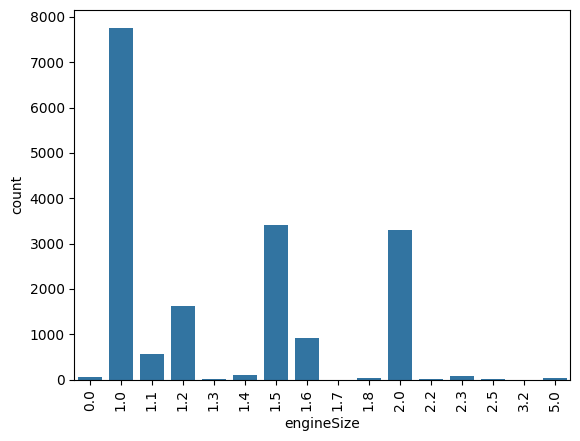

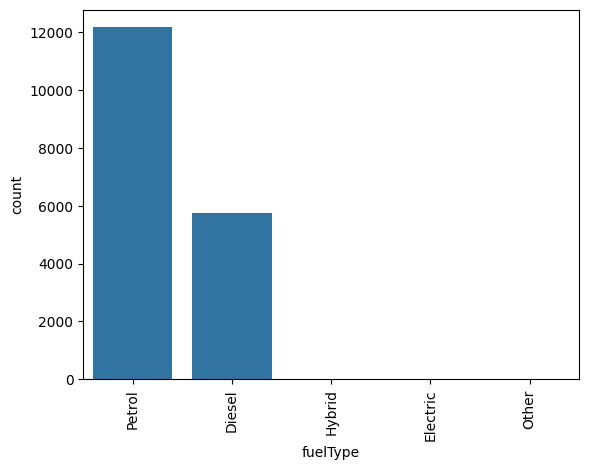

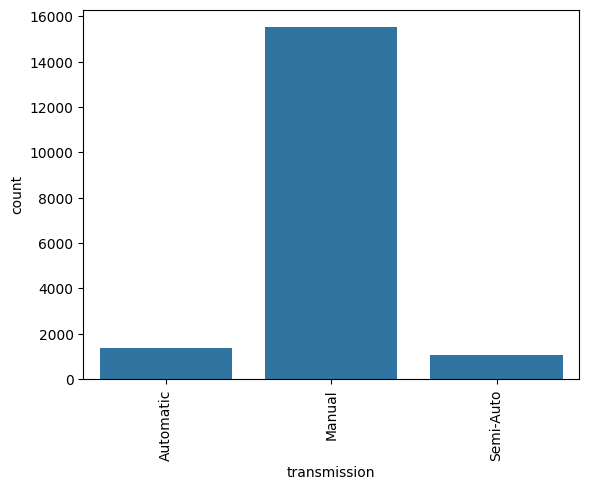

In [182]:
sns.countplot(x=df['year'])
plt.xticks(rotation=90)
plt.show()

sns.countplot(x=df['tax'])
plt.xticks(rotation=90)
plt.show()

sns.countplot(x=df['engineSize'])
plt.xticks(rotation=90)
plt.show()
sns.countplot(x=df['fuelType'])
plt.xticks(rotation=90)
plt.show()
sns.countplot(x=df['transmission'])
plt.xticks(rotation=90)
plt.show()

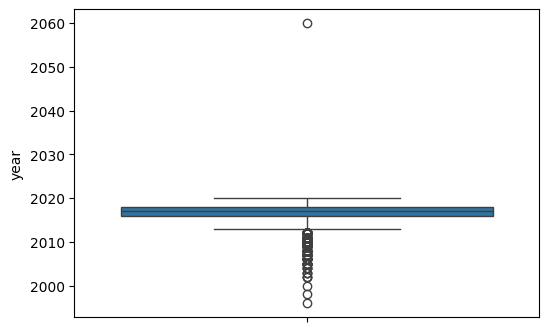

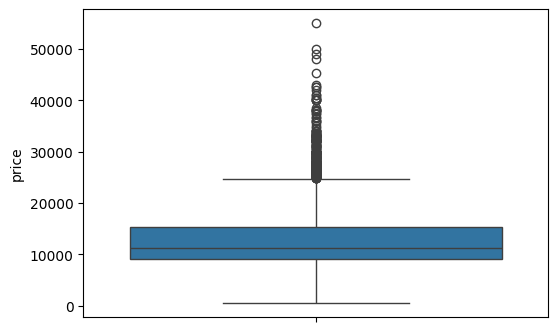

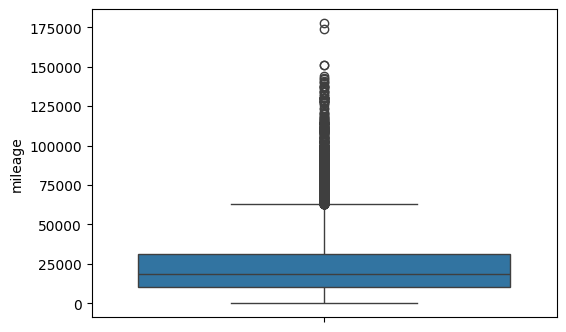

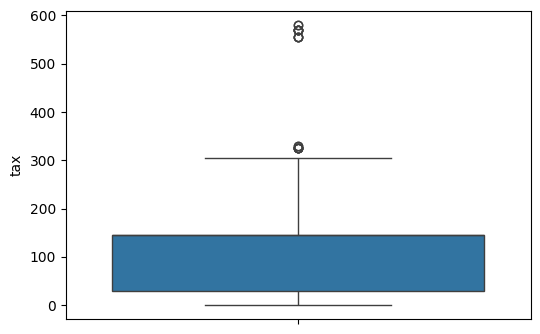

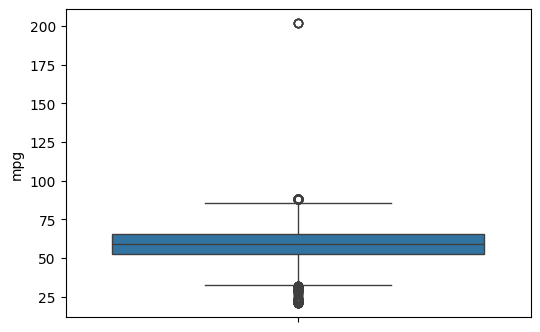

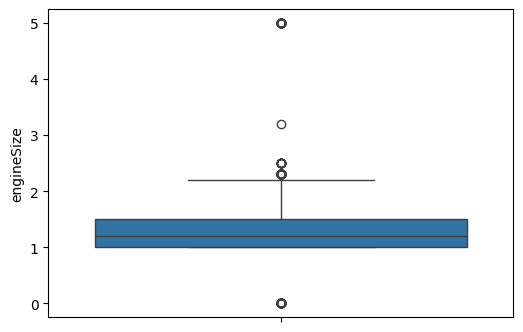

In [183]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(df[col])

<Axes: >

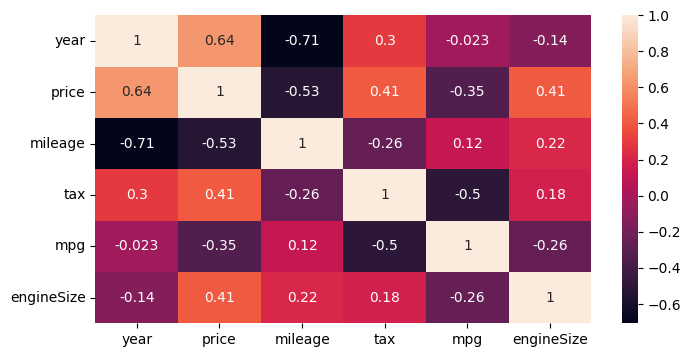

In [184]:
plt.figure(figsize=(8,4))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [185]:
df_cleaned=df.copy()
df_cleaned.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [186]:
df_cleaned.drop_duplicates(inplace=True)
df_cleaned.head()
df_cleaned.shape

(17812, 9)

In [187]:
df_cleaned.dtypes

model            object
year              int64
price             int64
transmission     object
mileage           int64
fuelType         object
tax               int64
mpg             float64
engineSize      float64
dtype: object

In [188]:
df_cleaned['year'].value_counts()

year
2017    4854
2018    3982
2019    3152
2016    2314
2015    1355
2014     799
2013     606
2020     252
2012     115
2011      94
2009      91
2010      67
2008      56
2007      32
2005      16
2006      13
2004       4
2003       3
2002       3
1998       1
1996       1
2000       1
2060       1
Name: count, dtype: int64

In [189]:
df_cleaned['transmission'].value_counts()

transmission
Manual       15383
Automatic     1354
Semi-Auto     1075
Name: count, dtype: int64

In [190]:
df_cleaned=pd.get_dummies(df_cleaned,columns=['transmission'])


In [191]:
df_cleaned.head()

,model,year,price,mileage,fuelType,tax,mpg,engineSize,transmission_Automatic,transmission_Manual,transmission_Semi-Auto
0,Fiesta,2017,12000,15944,Petrol,150,57.7,1.0,True,False,False
1,Focus,2018,14000,9083,Petrol,150,57.7,1.0,False,True,False
2,Focus,2017,13000,12456,Petrol,150,57.7,1.0,False,True,False
3,Fiesta,2019,17500,10460,Petrol,145,40.3,1.5,False,True,False
4,Fiesta,2019,16500,1482,Petrol,145,48.7,1.0,True,False,False


In [192]:
df_cleaned['fuelType'].value_counts()

fuelType
Petrol      12081
Diesel       5706
Hybrid         22
Electric        2
Other           1
Name: count, dtype: int64

In [193]:
df_cleaned=pd.get_dummies(df_cleaned,columns=['fuelType'])


In [194]:
df_cleaned.head()

,model,year,price,mileage,tax,mpg,engineSize,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,Fiesta,2017,12000,15944,150,57.7,1.0,True,False,False,False,False,False,False,True
1,Focus,2018,14000,9083,150,57.7,1.0,False,True,False,False,False,False,False,True
2,Focus,2017,13000,12456,150,57.7,1.0,False,True,False,False,False,False,False,True
3,Fiesta,2019,17500,10460,145,40.3,1.5,False,True,False,False,False,False,False,True
4,Fiesta,2019,16500,1482,145,48.7,1.0,True,False,False,False,False,False,False,True


In [195]:
df_cleaned['model'].value_counts()

model
 Fiesta                   6509
 Focus                    4555
 Kuga                     2208
 EcoSport                 1127
 C-MAX                     542
 Ka+                       523
 Mondeo                    512
 B-MAX                     350
 S-MAX                     294
 Grand C-MAX               247
 Galaxy                    227
 Edge                      205
 KA                        197
 Puma                       79
 Tourneo Custom             69
 Mustang                    57
 Grand Tourneo Connect      57
 Tourneo Connect            32
 Fusion                     16
 Streetka                    2
 Ranger                      1
 Escort                      1
 Transit Tourneo             1
Focus                        1
Name: count, dtype: int64

In [196]:
df_cleaned=pd.get_dummies(df_cleaned,columns=['model'])

In [197]:
df_cleaned.head()

,year,price,mileage,tax,mpg,engineSize,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_Diesel,...,model_ Mondeo,model_ Mustang,model_ Puma,model_ Ranger,model_ S-MAX,model_ Streetka,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus
0,2017,12000,15944,150,57.7,1.0,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2018,14000,9083,150,57.7,1.0,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2017,13000,12456,150,57.7,1.0,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2019,17500,10460,145,40.3,1.5,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2019,16500,1482,145,48.7,1.0,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [198]:
df_cleaned = df_cleaned.astype(int)

In [199]:
df_cleaned

,year,price,mileage,tax,mpg,engineSize,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_Diesel,...,model_ Mondeo,model_ Mustang,model_ Puma,model_ Ranger,model_ S-MAX,model_ Streetka,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus
0,2017,12000,15944,150,57,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2018,14000,9083,150,57,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2017,13000,12456,150,57,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2019,17500,10460,145,40,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2019,16500,1482,145,48,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,2017,8999,16700,150,47,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
17962,2014,7499,40700,30,57,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
17963,2015,9999,7010,20,67,1,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
17964,2018,8299,5007,145,57,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [200]:
from sklearn.preprocessing import StandardScaler
col=['year','mileage','tax','mpg']
scaler=StandardScaler()
df_cleaned[col] = scaler.fit_transform(df_cleaned[col])

In [204]:
df_cleaned.head()

,year,price,mileage,tax,mpg,engineSize,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_Diesel,...,model_ Mondeo,model_ Mustang,model_ Puma,model_ Ranger,model_ S-MAX,model_ Streetka,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus
0,0.067059,12000,-0.382994,0.591380,-0.042291,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0.554393,14000,-0.736317,0.591380,-0.042291,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0.067059,13000,-0.562616,0.591380,-0.042291,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1.041726,17500,-0.665405,0.510777,-1.720193,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1.041726,16500,-1.127749,0.510777,-0.930592,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [208]:
df_cleaned.columns

Index(['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize',
       'transmission_Automatic', 'transmission_Manual',
       'transmission_Semi-Auto', 'fuelType_Diesel', 'fuelType_Electric',
       'fuelType_Hybrid', 'fuelType_Other', 'fuelType_Petrol', 'model_ B-MAX',
       'model_ C-MAX', 'model_ EcoSport', 'model_ Edge', 'model_ Escort',
       'model_ Fiesta', 'model_ Focus', 'model_ Fusion', 'model_ Galaxy',
       'model_ Grand C-MAX', 'model_ Grand Tourneo Connect', 'model_ KA',
       'model_ Ka+', 'model_ Kuga', 'model_ Mondeo', 'model_ Mustang',
       'model_ Puma', 'model_ Ranger', 'model_ S-MAX', 'model_ Streetka',
       'model_ Tourneo Connect', 'model_ Tourneo Custom',
       'model_ Transit Tourneo', 'model_Focus'],
      dtype='object')

In [209]:
from scipy.stats import pearsonr

# --------------------------------
# Pearson Correlation Calculation
# --------------------------------

# List of features to check against target
selected_features = [
    'year', 'mileage', 'tax', 'mpg', 'engineSize',
       'transmission_Automatic', 'transmission_Manual',
       'transmission_Semi-Auto', 'fuelType_Diesel', 'fuelType_Electric',
       'fuelType_Hybrid', 'fuelType_Other', 'fuelType_Petrol', 'model_ B-MAX',
       'model_ C-MAX', 'model_ EcoSport', 'model_ Edge', 'model_ Escort',
       'model_ Fiesta', 'model_ Focus', 'model_ Fusion', 'model_ Galaxy',
       'model_ Grand C-MAX', 'model_ Grand Tourneo Connect', 'model_ KA',
       'model_ Ka+', 'model_ Kuga', 'model_ Mondeo', 'model_ Mustang',
       'model_ Puma', 'model_ Ranger', 'model_ S-MAX', 'model_ Streetka',
       'model_ Tourneo Connect', 'model_ Tourneo Custom',
       'model_ Transit Tourneo', 'model_Focus'
]

correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['price'])[0]
    for feature in selected_features
}

for feature, correlation in correlations.items():
    print(f"{feature:<30} : {correlation:.4f}")

year                           : 0.6357
mileage                        : -0.5305
tax                            : 0.4060
mpg                            : -0.3436
engineSize                     : 0.4956
transmission_Automatic         : 0.2080
transmission_Manual            : -0.2582
transmission_Semi-Auto         : 0.1406
fuelType_Diesel                : 0.1990
fuelType_Electric              : 0.0078
fuelType_Hybrid                : 0.0734
fuelType_Other                 : 0.0024
fuelType_Petrol                : -0.2045
model_ B-MAX                   : -0.1195
model_ C-MAX                   : -0.0881
model_ EcoSport                : 0.0110
model_ Edge                    : 0.2379
model_ Escort                  : -0.0147
model_ Fiesta                  : -0.3331
model_ Focus                   : 0.1126
model_ Fusion                  : -0.0615
model_ Galaxy                  : 0.1338
model_ Grand C-MAX             : -0.0348
model_ Grand Tourneo Connect   : 0.0299
model_ KA                     

In [210]:
cat_features = [
 'year', 'mileage', 'tax', 'mpg', 'engineSize',
       'transmission_Automatic', 'transmission_Manual',
       'transmission_Semi-Auto', 'fuelType_Diesel', 'fuelType_Electric',
       'fuelType_Hybrid', 'fuelType_Other', 'fuelType_Petrol', 'model_ B-MAX',
       'model_ C-MAX', 'model_ EcoSport', 'model_ Edge', 'model_ Escort',
       'model_ Fiesta', 'model_ Focus', 'model_ Fusion', 'model_ Galaxy',
       'model_ Grand C-MAX', 'model_ Grand Tourneo Connect', 'model_ KA',
       'model_ Ka+', 'model_ Kuga', 'model_ Mondeo', 'model_ Mustang',
       'model_ Puma', 'model_ Ranger', 'model_ S-MAX', 'model_ Streetka',
       'model_ Tourneo Connect', 'model_ Tourneo Custom',
       'model_ Transit Tourneo', 'model_Focus']
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

# Divide charges into 4 equal-frequency bins
df_cleaned['price_bin'] = pd.qcut(
    df_cleaned['price'],
    q=4,
    labels=False
)

chi2_results = {}

for col in cat_features:
    # Create contingency table
    contingency = pd.crosstab(
        df_cleaned[col],
        df_cleaned['price_bin']
    )

    # Chi-square test
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)

    # Decision
    decision = (
        'Reject Null (Keep Feature)'
        if p_val < alpha
        else 'Accept Null (Drop Feature)'
    )

    # Store results
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

# Convert results to a DataFrame for easier viewing
chi2_results_df = pd.DataFrame(chi2_results).T

print(chi2_results_df)

                             chi2_statistic   p_value  \
year                           12088.417248       0.0   
mileage                        42941.305795       0.0   
tax                             6192.677868       0.0   
mpg                             8896.319663       0.0   
engineSize                       3527.10004       0.0   
transmission_Automatic           651.165437       0.0   
transmission_Manual              921.709747       0.0   
transmission_Semi-Auto           239.984909       0.0   
fuelType_Diesel                  792.734615       0.0   
fuelType_Electric                  6.011469  0.111054   
fuelType_Hybrid                   28.281895  0.000003   
fuelType_Other                     2.994786   0.39243   
fuelType_Petrol                  816.312589       0.0   
model_ B-MAX                     376.692463       0.0   
model_ C-MAX                     220.607795       0.0   
model_ EcoSport                    89.91302       0.0   
model_ Edge                    

In [211]:
final_df=df_cleaned.copy()

In [212]:
final_df

,year,price,mileage,tax,mpg,engineSize,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_Diesel,...,model_ Mustang,model_ Puma,model_ Ranger,model_ S-MAX,model_ Streetka,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,price_bin
0,0.067059,12000,-0.382994,0.591380,-0.042291,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,2
1,0.554393,14000,-0.736317,0.591380,-0.042291,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,2
2,0.067059,13000,-0.562616,0.591380,-0.042291,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,2
3,1.041726,17500,-0.665405,0.510777,-1.720193,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,3
4,1.041726,16500,-1.127749,0.510777,-0.930592,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,0.067059,8999,-0.344061,0.591380,-1.029292,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
17962,-1.394942,7499,0.891875,-1.343079,-0.042291,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
17963,-0.907608,9999,-0.843071,-1.504284,0.944711,1,0,1,0,1,...,0,0,0,0,0,0,0,0,0,1
17964,0.554393,8299,-0.946220,0.510777,-0.042291,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [215]:
from sklearn.model_selection import train_test_split

In [216]:
X=final_df.drop('price',axis=1)
y=final_df['price']

In [217]:
train_test_split

<function sklearn.model_selection._split.train_test_split(*arrays, test_size=None, train_size=None, random_state=None, shuffle=True, stratify=None)>

In [218]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

In [220]:
from sklearn.linear_model import LinearRegression

In [221]:
model=LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [222]:
y_pred=model.predict(X_test)

In [224]:
from sklearn.metrics import r2_score

In [225]:
r2=r2_score(y_test,y_pred)

In [226]:
r2

0.8995518898036458

In [227]:
n=X_test.shape[0]
p=X_test.shape[1]
adjusted_r2=1-((1-r2))*(n-1)/(n-p-1)
adjusted_r2

0.8984687376505636